# Twitter Topic Modelling with LDA and BERTopic
## 1 Exploring dataset

#### 1.1 Load dataset

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

df = pd.read_csv('data/twitter.csv', encoding='utf-8')


#### 1.2 dataset info

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


#### 1.3 dataset top 5 rows

In [69]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


#### 1.4 Drop id column

In [70]:
df.drop(columns=['id'], inplace=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


#### 1.5 Unique labels

2
label
0    29720
1     2242
Name: count, dtype: int64


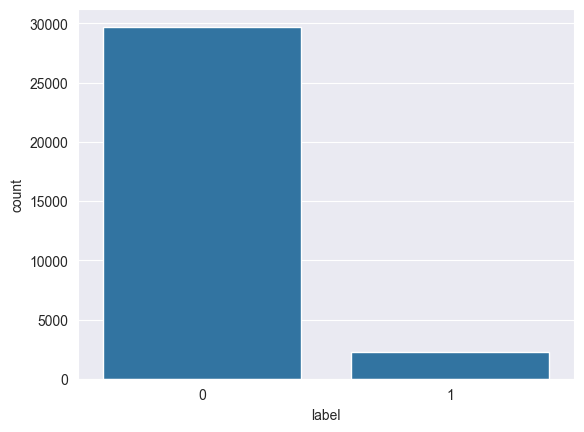

In [71]:
print(df['label'].nunique())
print(df['label'].value_counts())

# SNS plot to visualize
sns.countplot(x='label', data=df)
plt.show()

#### 1.6 Label Ratio

In [72]:
df['label'].value_counts(normalize=True)

label
0    0.929854
1    0.070146
Name: proportion, dtype: float64

**Note**: The label class is imbalanced

#### 1.6 Check tweet length

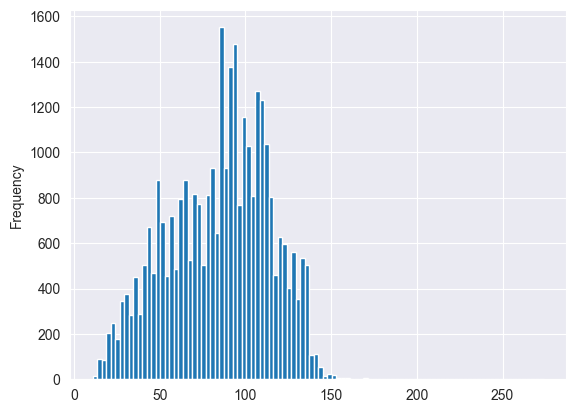

In [73]:
df['length'] = df['tweet'].apply(len)
df['length'].plot(bins=100, kind='hist')
plt.show()

## 2 Data cleanup
#### 2.1 Define preprocessor

In [74]:
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def ensure_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

def ensure_wordnet():
    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')

ensure_stopwords()
ensure_wordnet()

stop_words = set(stopwords.words('english'))

def preprocessor(text):
    # Remove HTML tags
    text = html.unescape(text)
    text = re.sub(r'<[^>]*>', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Handle hashtags
    text = re.sub(r'#(\w+)', r'\1', text)

    # Extract Emoticons
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)

    # Normalize text
    text = text.lower()
    text = re.sub(r'[\W]+', ' ', text)

    # Remove non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove emoticons
    text = text + ' ' + ' '.join(emoticons).replace('-', '')

    # Remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]

    tokens = [w for w in tokens if w.isalnum()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\durlo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### 2.2 Test preprocessor

In [75]:
text =  'In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her house and her murder remained unsolved. Twenty-two years later, the writer Mark Fuhrman (Christopher Meloni), who is a former LA detective that has fallen in disgrace for perjury in O.J. Simpson trial and moved to Idaho, decides to investigate the case with his partner Stephen Weeks (Andrew Mitchell) with the purpose of writing a book. The locals squirm and do not welcome them, but with the support of the retired detective Steve Carroll (Robert Forster) that was in charge of the investigation in the 70\'s, they discover the criminal and a net of power and money to cover the murder.<br /><br />"Murder in Greenwich" is a good TV movie, with the true story of a murder of a fifteen years old girl that was committed by a wealthy teenager whose mother was a Kennedy. The powerful and rich family…<'

cleaned_text = preprocessor(text)
print(cleaned_text)

1974 teenager martha moxley maggie grace move high class area belle greenwich connecticut mischief night eve halloween murdered backyard house murder remained unsolved twenty two year later writer mark fuhrman christopher meloni former la detective fallen disgrace perjury j simpson trial moved idaho decides investigate case partner stephen week andrew mitchell purpose writing book local squirm welcome support retired detective steve carroll robert forster charge investigation 70 discover criminal net power money cover murder murder greenwich good tv movie true story murder fifteen year old girl committed wealthy teenager whose mother kennedy powerful rich family


Test preprocessor on a Tweet

In [76]:
row = df.loc[df['length'].idxmax()]

print(row['tweet'])

cleaned_text = preprocessor(row['tweet'])
print(cleaned_text)

 @user lmfao pathetic #soit   #growup #funny #noonethere #iknowwhoitis ðððððððððððð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð±ð±ð¤ð¤ð±ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ð¤ðððððððâ¦
lmfao pathetic soit growup funny noonethere iknowwhoitis


#### 2.3 Remove Non-English Tweets

In [77]:
from langdetect import detect, LangDetectException

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False

# Enable to filter English tweets only
# It is disabled because LDA coherence is not good when filtering out non-English tweets
is_english_filter_enabled = False

if is_english_filter_enabled:
    df = df[df["tweet"].apply(is_english)]

    row = df.loc[df['length'].idxmax()]

    print(row['tweet'])
    df.shape

#### 2.4 Apply preprocessor

In [78]:
df['tweet_raw'] = df['tweet']
df['tweet'] = df['tweet'].apply(preprocessor)
print(df.loc[df['length'].idxmax()]['tweet'])

lmfao pathetic soit growup funny noonethere iknowwhoitis


## 3 Sampling and dataset split
#### 3.1 Sampling

In [79]:
def get_sampled_df(df, n_total, ratio, min_words=10, replace: bool = False):
    # keep only tweets with at least min_words tokens
    df = df[df["tweet"].astype(str).str.split().str.len() >= min_words]

    n_class1 = int(n_total * ratio)
    n_class0 = n_total - n_class1

    df_class0 = df[df['label'] == 0].sample(
        n=n_class0, random_state=42, replace=replace
    )
    df_class1 = df[df['label'] == 1].sample(
        n=n_class1,
        random_state=42,
        replace=replace
    )

    df_sampled = pd.concat([df_class0, df_class1]).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

    return df_sampled




# from imblearn.over_sampling import SMOTE
# from sklearn.feature_extraction.text import TfidfVectorizer
#
# vectorizer = TfidfVectorizer()
# X = vectorizer.fit_transform(df['tweet'])
# y = df['label']
#
# smote = SMOTE()
# X_res, y_res = smote.fit_resample(X, y)
#
# y_res.value_counts(normalize=True)

#### 3.1 Train test data split

In [80]:
from sklearn.model_selection import train_test_split

# Sample dataset since label1 is minority
df_sampled = get_sampled_df(df, 2000, 0.3, min_words=15, replace=True)
df_sampled['label'].value_counts(normalize=True)

# X = df['tweet']
# y = df['label']

X = df_sampled['tweet']
y = df_sampled['label']

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


0    trump new york co chair make racist gorilla re...
1    gun close shop ban sale dismantle system make ...
2    sirf ashiq log follow karen iqbal galib wasi f...
3    forever young man luks hot wen temper b alwys ...
4    2 sta way saying ripchristina saturday easier ...
Name: tweet, dtype: object


## 5 Topic Modeling
#### 5.0 Define coherence evaluation method

In [81]:
if is_colab():
    !pip install gensim

import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel


def print_topic_coherence(
    model,
    documents,
    vectorizer=None,
    model_type="auto",
    coherence="c_v",
    top_n_words=10,
    max_topics=None,
    exclude_outlier=True
):
    # Convert documents to list of strings
    documents = [str(doc) for doc in documents]

    # Auto-detect model type
    if model_type == "auto":
        if hasattr(model, "get_topics"):
            model_type = "bertopic"
        elif hasattr(model, "components_"):
            model_type = "lda"
        else:
            raise ValueError("Could not detect model type. Use model_type='bertopic' or model_type='lda'.")

    if model_type == "bertopic":
        cleaned_docs = model._preprocess_text(documents)

        vectorizer = model.vectorizer_model
        analyzer = vectorizer.build_analyzer()

        tokens = [analyzer(doc) for doc in cleaned_docs]

        topics = model.get_topics().copy()
        if exclude_outlier:
          topics.pop(-1, None)

        topic_words = []

        for topic_id, words_scores in topics.items():
            if exclude_outlier and topic_id == -1:
                continue

            words = [
                word
                for word, score in words_scores[:top_n_words]
                if word != ""
            ]

            if words:
                topic_words.append(words)

            if max_topics is not None and len(topic_words) >= max_topics:
                break

    elif model_type == "lda":
        if vectorizer is None:
            raise ValueError("For sklearn LDA, you must pass the fitted CountVectorizer as vectorizer.")

        analyzer = vectorizer.build_analyzer()
        tokens = [analyzer(doc) for doc in documents]

        feature_names = vectorizer.get_feature_names_out()

        topic_words = []

        for topic in model.components_:
            top_word_indices = topic.argsort()[-top_n_words:][::-1]
            words = [feature_names[i] for i in top_word_indices]
            topic_words.append(words)

            if max_topics is not None and len(topic_words) >= max_topics:
                break

    else:
        raise ValueError("model_type must be 'auto', 'bertopic', or 'lda'.")

    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence=coherence
    )

    coherence_score = coherence_model.get_coherence()

    print(f"Model type: {model_type}")
    print(f"Number of topics evaluated: {len(topic_words)}")
    print(f"Top words per topic: {top_n_words}")
    print(f"Coherence Score ({coherence}): {coherence_score}")

    return coherence_score

def save_topic_model_results_to_csv(results, output_path, model_type="lda"):
    rows = []

    for i, result in enumerate(results):

        row = {
            "model_type": model_type,
            "run_id": i
        }

        # Dictionary-based results
        if isinstance(result, dict):
            row["n_topics"] = result.get("n_topics")
            row["nr_topic"] = result.get("nr_topic")
            row["coherence"] = result.get("coherence")
            row["outlier_percentage"] = result.get("outlier_percentage", np.nan)

            x_topics = (
                result.get("X_topics")
                if "X_topics" in result
                else result.get("topics")
            )

        if X_topics is None:
            raise ValueError("X_topics must not be None.")

        # Store X_topics/topics safely as a compact string
        if x_topics is not None:
            try:
                x_topics_array = np.asarray(x_topics)

                row["x_topics_shape"] = str(x_topics_array.shape)

                # Do not save huge document-topic matrices directly in full
                if x_topics_array.ndim == 2:
                    dominant_topics = x_topics_array.argmax(axis=1)
                    row["dominant_topics"] = ",".join(map(str, dominant_topics))
                else:
                    row["dominant_topics"] = ",".join(map(str, x_topics_array))

            except Exception:
                row["x_topics_shape"] = None
                row["dominant_topics"] = str(x_topics)
        else:
            row["x_topics_shape"] = None
            row["dominant_topics"] = None

        rows.append(row)

    df_results = pd.DataFrame(rows)
    df_results.to_csv(output_path, index=False)

    print(f"Saved {len(df_results)} {model_type} results to {output_path}")

    return df_results

#### 5.1 LDA

In [82]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

lda_results = []

for n_topics in [5, 8, 10, 12, 15, 20]:

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=3,
        max_df=0.8,
        max_features=10000,
        ngram_range=(1, 2)
    )

    X_vec = vectorizer.fit_transform(X)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=20,
        doc_topic_prior=0.1,
        topic_word_prior=0.01
    )

    X_topics = lda.fit_transform(X_vec)

    coherence = print_topic_coherence(
        lda,
        X,
        vectorizer=vectorizer,
        model_type="lda",
        top_n_words=10
    )

    lda_results.append({
        "n_topics": n_topics,
        "lda": lda,
        "vectorizer": vectorizer,
        "X_vec": X_vec,
        "X_topics": X_topics,
        "coherence": coherence
    })

best_result = max(lda_results, key=lambda x: x["coherence"])

best_lda = best_result["lda"]
best_vectorizer = best_result["vectorizer"]
best_X_vec = best_result["X_vec"]
best_X_topics = best_result["X_topics"]
best_n_topics = best_result["n_topics"]
best_coherence = best_result["coherence"]

print("Best number of topics:", best_n_topics)
print("Best coherence:", best_coherence)

save_topic_model_results_to_csv(
    lda_results,
    "output/lda_results.csv",
    model_type="lda"
)

X_topics = best_X_topics

Model type: lda
Number of topics evaluated: 5
Top words per topic: 10
Coherence Score (c_v): 0.5958012553018746
Model type: lda
Number of topics evaluated: 8
Top words per topic: 10
Coherence Score (c_v): 0.4901375445962336
Model type: lda
Number of topics evaluated: 10
Top words per topic: 10
Coherence Score (c_v): 0.4863246212329897
Model type: lda
Number of topics evaluated: 12
Top words per topic: 10
Coherence Score (c_v): 0.6420962822328247
Model type: lda
Number of topics evaluated: 15
Top words per topic: 10
Coherence Score (c_v): 0.6864075837863357
Model type: lda
Number of topics evaluated: 20
Top words per topic: 10
Coherence Score (c_v): 0.6980686439325335
Best number of topics: 20
Best coherence: 0.6980686439325335
Saved 6 lda results to output/lda_results.csv


#### 5.1.1 Print/View topics

In [83]:
def print_topics(model, vectorizer, n_top_words=5):
    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]

        print(f"Topic {topic_idx + 1}:")
        print(" ".join(top_words))


#### 5.1.2 Print LDA

In [84]:
print_topics(best_lda, vectorizer, n_top_words=5)
topic_cat1 = X_topics[:, 1].argsort()[::-1]


for iter_idx, topic_idx in enumerate(topic_cat1[:3]):
    print('\nTopic #%d:' % (iter_idx + 1))
    print(df['tweet'][topic_idx][:300], '...')

Topic 1:
lol suppo president pure comedy
Topic 2:
la land ur make week
Topic 3:
judge tht work let need
Topic 4:
bear polar polar bear climb racing bear climb
Topic 5:
06 13 day warnung dwd wetterwarnung
Topic 6:
day mom pop good mom pop
Topic 7:
happy good watch bihday sir
Topic 8:
young na hot sexy horny
Topic 9:
dare pig rest racist canada
Topic 10:
feminist help plz decided reading
Topic 11:
trump obama chair michelle michelle male
Topic 12:
new yr left came clean
Topic 13:
25 10 2016 right fail
Topic 14:
poetry let free look going
Topic 15:
dust miss year pathetic coach
Topic 16:
blog silver blog silver silver gold gold
Topic 17:
day let sa wear got
Topic 18:
im trump bc bc im asian
Topic 19:
follow leave today friend medium
Topic 20:
new life gay job love

Topic #1:
helping little people manage big emotion feeling disappointment ...

Topic #2:
one make quote ...

Topic #3:
ferrari sake championship gp clearly turning point rb ferrari mercs ...


#### 5.1.3 Visualise topics

In [85]:
if is_colab():
    !pip install pyLDAvis

import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

vis = pyLDAvis.lda_model.prepare(
    best_lda,
    best_X_vec,
    best_vectorizer
)

vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
3      0.026539 -0.334997       1        1  9.885692
15     0.273950  0.091764       2        1  8.246100
7     -0.064089 -0.162178       3        1  6.679400
11     0.104507 -0.067508       4        1  6.013676
13    -0.145436  0.070280       5        1  5.920072
10     0.224672  0.075387       6        1  5.696078
17     0.103468 -0.118323       7        1  5.606059
12    -0.086464 -0.133218       8        1  5.315134
18    -0.183919  0.007599       9        1  4.892953
4     -0.115664  0.074749      10        1  4.757794
0     -0.015950 -0.029607      11        1  4.471685
5     -0.085540  0.095898      12        1  4.254799
2     -0.038515  0.054976      13        1  4.221384
1      0.007006 -0.023014      14        1  4.075177
16    -0.008989  0.113329      15        1  4.054531
19     0.087737  0.126623      16        1  3.526784
8      0.111966 -0.033431      17        1  3.419140
9     -0.079800  0.050668      18        1  3.417388
14    -0.042250  0.080544      19        1  2.899240
6     -0.073228  0.060460      20        1  2.646914, topic_info=              Term        Freq       Total Category  logprob  loglift
579           bear  382.000000  382.000000  Default  30.0000  30.0000
3183    polar bear  382.000000  382.000000  Default  29.0000  29.0000
3182         polar  382.000000  382.000000  Default  28.0000  28.0000
911   climb racing  255.000000  255.000000  Default  27.0000  27.0000
910          climb  255.000000  255.000000  Default  26.0000  26.0000
...            ...         ...         ...      ...      ...      ...
3827            sm    6.174476   21.111564  Topic20  -5.2768   2.4024
1319           eid    6.174464   22.921945  Topic20  -5.2768   2.3201
3406        really    6.357307   30.111697  Topic20  -5.2476   2.0765
4484          week    7.004625   74.559977  Topic20  -5.1506   1.2667
2528          love    6.318350  117.137268  Topic20  -5.2537   0.7119

[911 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
0        10  0.816998           00
0        12  0.188538           00
2        10  1.001392   00 warnung
8        10  0.984008           06
15       10  0.996857           08
...     ...       ...          ...
4684      4  1.001041   yr endless
4685      8  1.005819  yr idolized
4693     12  0.990616          zag
4698     12  0.990616          zig
4699     12  0.990616      zig zag

[1337 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 16, 8, 12, 14, 11, 18, 13, 19, 5, 1, 6, 3, 2, 17, 20, 9, 10, 15, 7])

#### 5.2 BERTopic

In [86]:
if is_colab():
    !pip install bertopic
    !pip install sentence_transformers

In [87]:
from bertopic import BERTopic
import torch
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

nr_topics = [10, 20, 30, 50, 'auto', None]

vectorizers = [
    CountVectorizer(stop_words="english", max_df=0.1, ngram_range=(1, 1)),
    CountVectorizer(stop_words="english", min_df=1, max_df=0.95, ngram_range=(1, 2)),
    CountVectorizer(stop_words="english", min_df=2, max_df=0.9, ngram_range=(1, 2)),
    CountVectorizer(stop_words="english", min_df=3, max_df=0.9, ngram_range=(1, 2)),
]

results = []

for nr_topic in nr_topics:
    for vectorizer in vectorizers:
        topic_model = BERTopic(
            embedding_model=embedding_model,
            vectorizer_model=vectorizer,
            language="english",
            nr_topics=nr_topic,
            calculate_probabilities=True,
            verbose=True
        )

        topics, probs = topic_model.fit_transform(X.tolist())

        coherence = print_topic_coherence(
            topic_model,
            X,
            model_type="bertopic",
            top_n_words=10
        )

        topic_info = topic_model.get_topic_info()
        n_topics = len(topic_info[topic_info["Topic"] != -1])

        outlier_count = topic_info.loc[topic_info["Topic"] == -1, "Count"].sum()
        outlier_percentage = outlier_count / len(X) * 100

        results.append({
            "vectorizer": vectorizer,
            "coherence": coherence,
            "n_topics": n_topics,
            "nr_topic": nr_topic,
            "outlier_percentage": outlier_percentage,
            "topics": topics,
            "probs": probs,
            "topic_model": topic_model
        })

best_result = max(results, key=lambda x: x["coherence"])
best_vectorizer = best_result["vectorizer"]
best_coherence = best_result["coherence"]
best_n_topics = best_result["n_topics"]
best_nr_topics = best_result["nr_topic"]
best_outlier_percentage = best_result["outlier_percentage"]
topics = best_result["topics"]
probs = best_result["probs"]
topic_model = best_result["topic_model"]

print(f"Best coherence: {best_coherence:.2f}")
print(f"Best number of topics: {best_n_topics}")
print(f"Best number of topics: {best_nr_topics}")
print(f"Outlier percentage: {best_outlier_percentage:.2f}%")

save_topic_model_results_to_csv(
    results,
    "output/bertopic_results.csv",
    model_type="bertopic"
)

Torch: 2.12.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 Ti


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6866.40it/s]
2026-05-27 09:39:40,973 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 63/63 [00:00<00:00, 110.57it/s]
2026-05-27 09:39:41,563 - BERTopic - Embedding - Completed ✓
2026-05-27 09:39:41,563 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 09:39:44,642 - BERTopic - Dimensionality - Completed ✓
2026-05-27 09:39:44,644 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 09:39:45,447 - BERTopic - Cluster - Completed ✓
2026-05-27 09:39:45,449 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-27 09:39:45,558 - BERTopic - Representation - Completed ✓
2026-05-27 09:39:45,560 - BERTopic - Topic reduction - Reducing number of topics
2026-05-27 09:39:45,567 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 09:39:45,600 - BERTopic - Representation - C

Model type: bertopic
Number of topics evaluated: 9
Top words per topic: 10
Coherence Score (c_v): 0.6055492138896648


Batches: 100%|██████████| 63/63 [00:00<00:00, 64.99it/s]
2026-05-27 09:39:59,659 - BERTopic - Embedding - Completed ✓
2026-05-27 09:39:59,659 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 09:40:02,987 - BERTopic - Dimensionality - Completed ✓
2026-05-27 09:40:02,989 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 09:40:03,528 - BERTopic - Cluster - Completed ✓
2026-05-27 09:40:03,528 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-27 09:40:03,604 - BERTopic - Representation - Completed ✓
2026-05-27 09:40:03,604 - BERTopic - Topic reduction - Reducing number of topics
2026-05-27 09:40:03,622 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 09:40:03,685 - BERTopic - Representation - Completed ✓
2026-05-27 09:40:03,686 - BERTopic - Topic reduction - Reduced number of topics from 86 to 10
2026-05-27 09:40:16,049 - BERTopic - Embedding - Tra

Model type: bertopic
Number of topics evaluated: 9
Top words per topic: 10
Coherence Score (c_v): 0.860860746589889


...

Batches: 100%|██████████| 63/63 [00:00<00:00, 87.18it/s] 
2026-05-27 09:45:54,675 - BERTopic - Embedding - Completed ✓
2026-05-27 09:45:54,675 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 09:45:57,630 - BERTopic - Dimensionality - Completed ✓
2026-05-27 09:45:57,632 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 09:45:58,163 - BERTopic - Cluster - Completed ✓
2026-05-27 09:45:58,166 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 09:45:58,221 - BERTopic - Representation - Completed ✓
2026-05-27 09:46:10,997 - BERTopic - Embedding - Transforming documents to embeddings.


Model type: bertopic
Number of topics evaluated: 84
Top words per topic: 10
Coherence Score (c_v): 0.6339084115184038


Batches: 100%|██████████| 63/63 [00:00<00:00, 78.74it/s]
2026-05-27 09:46:11,810 - BERTopic - Embedding - Completed ✓
2026-05-27 09:46:11,810 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 09:46:14,798 - BERTopic - Dimensionality - Completed ✓
2026-05-27 09:46:14,798 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 09:46:15,276 - BERTopic - Cluster - Completed ✓
2026-05-27 09:46:15,280 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 09:46:15,332 - BERTopic - Representation - Completed ✓


Model type: bertopic
Number of topics evaluated: 84
Top words per topic: 10
Coherence Score (c_v): 0.578324727302148
Best coherence: 0.89
Best number of topics: 19
Best number of topics: 20
Outlier percentage: 7.30%
Saved 24 bertopic results to output/bertopic_results.csv


,model_type,run_id,n_topics,nr_topic,coherence,outlier_percentage,x_topics_shape,dominant_topics
0,bertopic,0,9,10,0.605549,9.30,"(2000,)","2,-1,0,-1,1,4,1,7,1,-1,0,0,-1,0,1,3,0,0,1,1,5,..."
1,bertopic,1,9,10,0.860861,8.05,"(2000,)","1,-1,0,0,0,-1,0,6,0,-1,0,0,-1,0,0,2,0,0,2,0,4,..."
2,bertopic,2,9,10,0.757394,8.40,"(2000,)","1,-1,0,0,0,3,-1,6,0,-1,0,0,-1,0,0,2,0,0,4,0,0,..."
3,bertopic,3,9,10,0.631810,5.35,"(2000,)","1,0,0,0,0,3,0,7,0,-1,0,0,-1,0,0,2,0,0,4,0,3,0,..."
4,bertopic,4,19,20,0.706442,8.90,"(2000,)","3,-1,0,1,4,5,1,13,4,-1,0,0,-1,0,1,2,0,0,7,1,10..."
5,bertopic,5,19,20,0.890993,7.30,"(2000,)","3,-1,0,1,1,5,-1,12,1,-1,0,0,2,0,1,2,0,0,6,1,8,..."
6,bertopic,6,19,20,0.674132,8.15,"(2000,)","4,-1,2,-1,1,5,1,11,1,-1,2,2,-1,2,1,3,2,0,12,1,..."
7,bertopic,7,19,20,0.519459,7.70,"(2000,)","1,-1,0,7,4,-1,2,12,4,-1,0,0,5,0,2,3,0,0,8,2,16..."
8,bertopic,8,29,30,0.802195,10.05,"(2000,)","2,-1,0,8,1,5,1,19,1,-1,0,4,5,4,6,3,4,9,22,20,2..."
9,bertopic,9,29,30,0.885298,8.75,"(2000,)","4,-1,3,8,25,7,5,18,6,-1,2,2,1,2,5,1,2,0,21,19,..."


#### 5.2.1 Extracting topics

In [88]:
freq = topic_model.get_topic_info(); freq.head(5)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,146,-1_new_dust_forex_gold forex,"[new, dust, forex, gold forex, silver gold, bl...",[month guitar player direct tv commercial gene...
1,0,665,0_poetry_day_na_follow,"[poetry, day, na, follow, sexy, young, happy, ...",[ariellesloth na kinky horny young naughty nud...
2,1,311,1_yr_lie_activist_contempt left,"[yr, lie, activist, contempt left, clarity cam...",[8 yr endless lie contempt left activist u rea...
3,2,150,2_polar_polar bear_bear_bear climb,"[polar, polar bear, bear, bear climb, climb, c...",[payintheusa polar bear climb racing angry pol...
4,3,128,3_trump_obama_michelle_chair,"[trump, obama, michelle, chair, michelle male,...",[billionaire chair trump say hope obama dy mic...


**Select the most frequent topic**

In [89]:
topic_model.get_topic(0)

[('poetry', 0.022300885360949246),
 ('day', 0.017650103100479198),
 ('na', 0.015873565192457733),
 ('follow', 0.015540314787917014),
 ('sexy', 0.014944516662824687),
 ('young', 0.014665441559621833),
 ('happy', 0.013860660629596521),
 ('porn', 0.013461027218377063),
 ('horny', 0.013461027218377063),
 ('naughty', 0.013461027218377063)]

#### 5.2.3 Visualisation

In [90]:
topic_model.visualize_topics()

#### 5.2.4 Visualise Topic Probabilities

In [91]:
topic_model.visualize_distribution(probs[200], min_probability=0.005)

#### 5.2.5 Visualise Topic Hierarchy

In [92]:
topic_model.visualize_hierarchy(top_n_topics=50)

#### 5.2.6 Visualise Terms

In [93]:
topic_model.visualize_barchart(top_n_topics=5)

#### 5.2.7 Visualise Topic Similarity

In [94]:
topic_model.visualize_heatmap(n_clusters=5, width=1000, height=1000)

#### 5.2.8 Visualise Term Score Decline

In [95]:
topic_model.visualize_term_rank()